In [1]:
import pandas as pd
import numpy as np

In [ ]:
df1 = pd.read_csv(r"BenignTraffic3.pcap_Flow.csv")
df2 = pd.read_csv(r"DDoS-ACK_Fragmentation2.pcap_Flow.csv")
df3 = pd.read_csv(r"DDoS-HTTP_Flood-.pcap_Flow.csv")
df4 = pd.read_csv(r"DDoS-ICMP_Flood3.pcap_Flow.csv")
df5 = pd.read_csv(r"DDoS-ICMP_Fragmentation.pcap_Flow.csv")
df6 = pd.read_csv(r"DictionaryBruteForce.pcap_Flow (1).csv")
df7 = pd.read_csv(r"DoS-HTTP_Flood1.pcap_Flow.csv")
df8 = pd.read_csv(r"DoS-SYN_Flood7.pcap_Flow.csv")
df9 = pd.read_csv(r"DoS-UDP_Flood8.pcap_Flow.csv")
df10 = pd.read_csv(r"Mirai-greeth_flood.pcap_Flow.csv")
df11 = pd.read_csv(r"DNS_Spoofing.pcap_Flow.csv")
df12 = pd.read_csv(r"MITM-ArpSpoofing.pcap_Flow.csv")
df13 = pd.read_csv(r"SqlInjection.pcap_Flow.csv")
df14 = pd.read_csv(r"Uploading_Attack.pcap_Flow.csv")
df15 = pd.read_csv(r"VulnerabilityScan.pcap_Flow.csv")
df16 = pd.read_csv(r"ml proex\XSS.pcap_Flow.csv")

data = pd.concat([df1,df2,df3,df4,df5,df6,df7,df8,df9,df10,df11,df12,df13,df14,df15,df16], ignore_index=True)
data.head()

data.columns
data['Label']


0          benign
1          benign
2          benign
3          benign
4          benign
            ...  
3131839       XSS
3131840       XSS
3131841       XSS
3131842       XSS
3131843       XSS
Name: Label, Length: 3131844, dtype: object

In [5]:
# List of columns to keep
columns_to_keep = ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',
       'URG Flag Count', 'CWR Flag Count', 'ECE Flag Count', 'Down/Up Ratio',
       'Average Packet Size', 'Fwd Segment Size Avg', 'Bwd Segment Size Avg',
       'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg',
       'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg', 'Bwd Bulk Rate Avg',
       'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets',
       'Subflow Bwd Bytes', 'FWD Init Win Bytes', 'Bwd Init Win Bytes',
       'Fwd Act Data Pkts', 'Fwd Seg Size Min', 'Active Mean', 'Active Std',
       'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max',
       'Idle Min', 'Label']

# Filter the dataframe to keep only the columns in the list
data = data[columns_to_keep]

# Display the first few rows of the filtered dataframe
data.head()
data['Label']

0          benign
1          benign
2          benign
3          benign
4          benign
            ...  
3131839       XSS
3131840       XSS
3131841       XSS
3131842       XSS
3131843       XSS
Name: Label, Length: 3131844, dtype: object

In [6]:
data.to_csv("merged_dataset.csv", index=False)


In [2]:
import numpy as np
import seaborn as sns
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import LabelEncoder

In [7]:
df=pd.read_csv("merged_dataset.csv")
df.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Len

In [7]:
df.shape

(3131844, 84)

In [8]:
df

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.137.227-52.27.254.108-35863-8443-6,192.168.137.227,35863,52.27.254.108,8443,6,08-10-2022 14:47,715827,11,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign
1,192.168.137.83-13.225.196.108-58982-443-6,192.168.137.83,58982,13.225.196.108,443,6,08-10-2022 14:47,407181,92,103,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign
2,192.168.137.175-54.74.35.22-56367-443-6,192.168.137.175,56367,54.74.35.22,443,6,08-10-2022 14:47,26377049,909,847,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign
3,192.168.137.175-52.211.121.111-51251-443-6,192.168.137.175,51251,52.211.121.111,443,6,08-10-2022 14:47,702234,13,7,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign
4,192.168.137.175-52.30.149.214-40788-443-6,192.168.137.175,40788,52.30.149.214,443,6,08-10-2022 14:47,825762,9,8,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3131839,192.168.137.206-47.112.162.49-29640-32100-17,192.168.137.206,29640,47.112.162.49,32100,17,14-02-2023 11:49,270833,1,1,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,XSS
3131840,192.168.137.206-18.182.200.45-29640-32100-17,192.168.137.206,29640,18.182.200.45,32100,17,14-02-2023 11:49,203611,1,1,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,XSS
3131841,192.168.137.206-3.221.182.58-29640-32100-17,192.168.137.206,29640,3.221.182.58,32100,17,14-02-2023 11:49,68256,1,1,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,XSS
3131842,35.185.44.250-192.168.137.34-443-54482-6,35.185.44.250,443,192.168.137.34,54482,6,14-02-2023 12:24,119317359,126,125,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,XSS


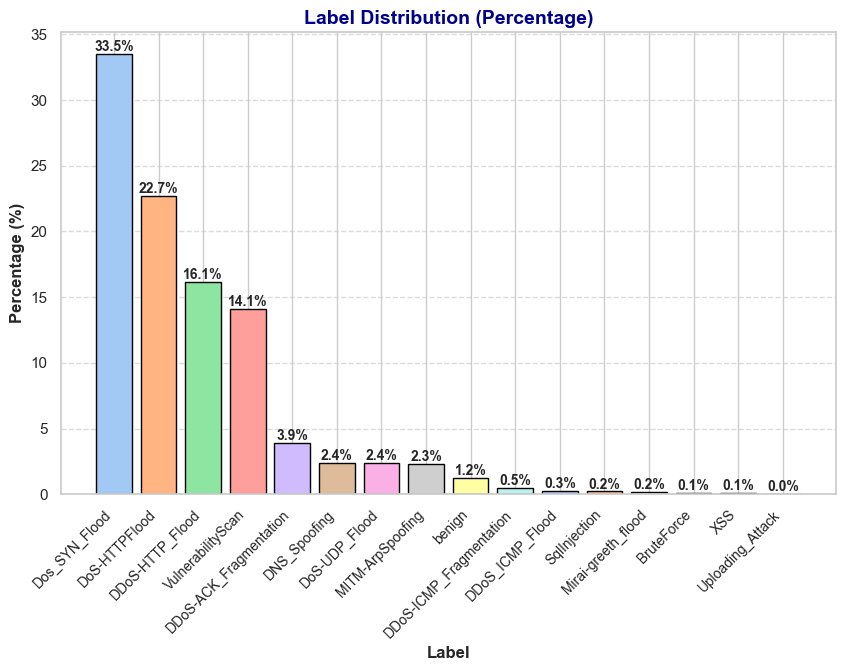

In [68]:
# Count unique labels and convert to percentages
a = df['Label'].value_counts(normalize=True) * 100  # Convert to percentage

# Set figure size
plt.figure(figsize=(10, 6))

# Create a bar plot with Seaborn styling
colors = sns.color_palette("pastel", len(a))  # Use a pastel color palette
bars = plt.bar(a.index, a.values, color=colors, edgecolor='black')

# Add labels on top of bars (showing percentage values)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.1f}%", ha='center', va='bottom', 
             fontsize=10, fontweight='bold')

# Add titles and labels
plt.xlabel("Label", fontsize=12, fontweight='bold')
plt.ylabel("Percentage (%)", fontsize=12, fontweight='bold')
plt.title("Label Distribution (Percentage)", fontsize=14, fontweight='bold', color='darkblue')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


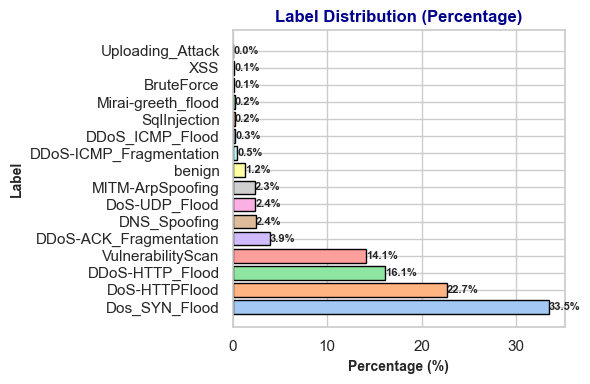

In [69]:
# Count unique labels and convert to percentages
a = df['Label'].value_counts(normalize=True) * 100  # Convert to percentage

# Set a smaller figure size
plt.figure(figsize=(6, 4))

# Create a horizontal bar plot with Seaborn styling
colors = sns.color_palette("pastel", len(a))  # Use a pastel color palette
bars = plt.barh(a.index, a.values, color=colors, edgecolor='black')

# Add labels on top of bars (showing percentage values)
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}%", va='center', ha='left', 
             fontsize=8, fontweight='bold')

# Add titles and labels with smaller font sizes
plt.xlabel("Percentage (%)", fontsize=10, fontweight='bold')
plt.ylabel("Label", fontsize=10, fontweight='bold')
plt.title("Label Distribution (Percentage)", fontsize=12, fontweight='bold', color='darkblue')

# Adjust layout to avoid label cutoff
plt.tight_layout()

# Show the plot
plt.show()

DATA PREPROCCESSING

In [8]:
print(df.isnull().sum())
has_null=df.isnull().any().any()
has_null
columns_with_null = df.columns[df.isnull().any()]
print("Columns with null values:", columns_with_null)
df=df.dropna()
df.shape

Flow ID      0
Src IP       0
Src Port     0
Dst IP       0
Dst Port     0
            ..
Idle Mean    0
Idle Std     0
Idle Max     0
Idle Min     0
Label        0
Length: 84, dtype: int64
Columns with null values: Index(['Flow Bytes/s'], dtype='object')


(3091195, 84)

In [9]:
df=df.drop_duplicates()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.shape
df.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Len

In [10]:
cat_columns = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", cat_columns)

#Dropping unnecessary columns
df.drop(columns=["Flow ID", "Src IP", "Dst IP", "Timestamp"], inplace=True)

# Drop columns where all values are zero
df = df.loc[:, (df != 0).any(axis=0)]

columns_dropped = df.columns[(df == 0).all(axis=0)]
print("Columns dropped:", columns_dropped)

Categorical Columns: Index(['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label'], dtype='object')
Columns dropped: Index([], dtype='object')


In [11]:
X=df.drop(['Label'],axis=1)
y=df['Label']
X.shape 

(3084357, 72)

In [12]:
columns_with_zeros = X.columns[(X == 0).any()]

print("Columns with zeros:", columns_with_zeros)

Columns with zeros: Index(['Src Port', 'Dst Port', 'Protocol', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow IAT Std', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
       'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max',
       'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
       'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'CWR Flag Count', 'ECE Flag Count', 'Down/Up Ratio',
       'Average Packet Size',

In [13]:
X.replace([np.inf, -np.inf], np.mean, inplace=True)
X.shape


(3084357, 72)

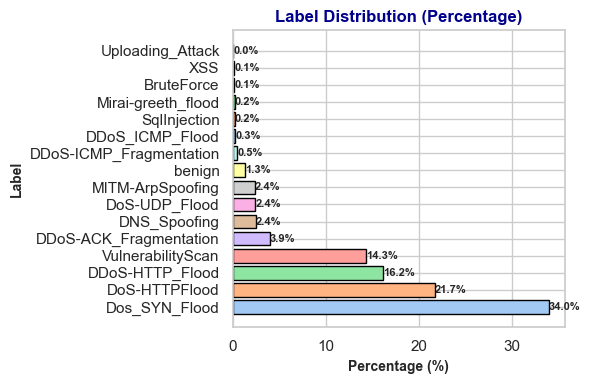

In [76]:
# Count unique labels and convert to percentages
a = df['Label'].value_counts(normalize=True) * 100  # Convert to percentage

# Set a smaller figure size
plt.figure(figsize=(6, 4))

# Create a horizontal bar plot with Seaborn styling
colors = sns.color_palette("pastel", len(a))  # Use a pastel color palette
bars = plt.barh(a.index, a.values, color=colors, edgecolor='black')

# Add labels on top of bars (showing percentage values)
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}%", va='center', ha='left', 
             fontsize=8, fontweight='bold')

# Add titles and labels with smaller font sizes
plt.xlabel("Percentage (%)", fontsize=10, fontweight='bold')
plt.ylabel("Label", fontsize=10, fontweight='bold')
plt.title("Label Distribution (Percentage)", fontsize=12, fontweight='bold', color='darkblue')

# Adjust layout to avoid label cutoff
plt.tight_layout()

# Show the plot
plt.show()


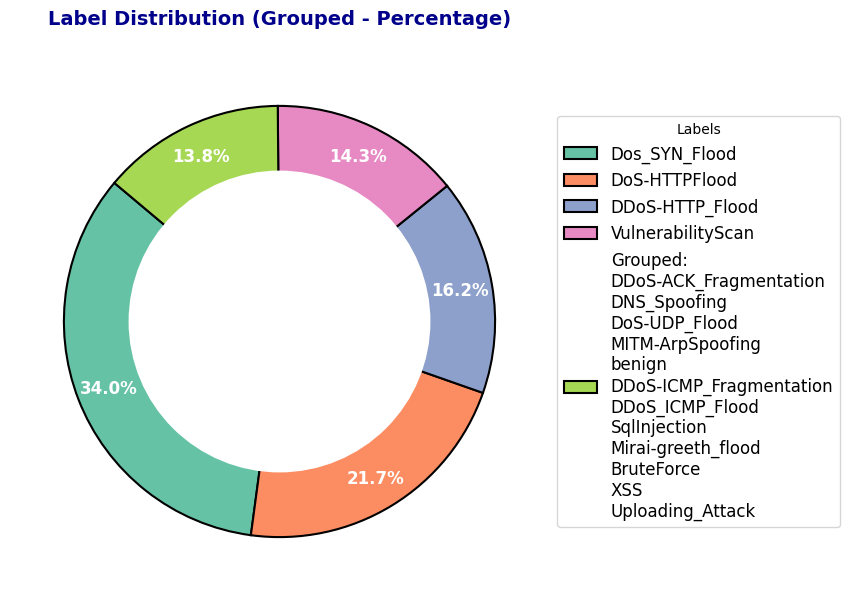

In [16]:
# Count unique labels and convert to percentages
threshold = 5  # Set a threshold for grouping smaller categories
value_counts = df['Label'].value_counts(normalize=True) * 100  # Convert to percentage

# Identify smaller and larger categories
small_categories = value_counts[value_counts < threshold]
large_categories = value_counts[value_counts >= threshold]

# Store names of grouped categories and format them properly
grouped_labels = list(small_categories.index)

# Create a new Series with grouped values
if not small_categories.empty:
    grouped_label_text = "Grouped:\n" + "\n".join(grouped_labels)  # Each category in "Grouped" appears on a new line
    grouped_data = large_categories.copy()
    grouped_data[grouped_label_text] = small_categories.sum()  # Show all grouped categories
else:
    grouped_data = value_counts  # No small categories to group

# Set figure size
plt.figure(figsize=(12, 7))

# Define colors using Seaborn
colors = sns.color_palette("Set2", len(grouped_data))

# Create pie chart
wedges, texts, autotexts = plt.pie(grouped_data.values, autopct='%1.1f%%',
                                   colors=colors, startangle=140, pctdistance=0.85,
                                   wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
                                   textprops={'fontsize': 12})

# Format percentage labels inside slices
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Draw a circle at the center to create a donut chart effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

# Add a legend outside the pie chart, ensuring grouped items appear as separate lines
plt.legend(wedges, grouped_data.index, title="Labels", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12)

# Add a title
plt.title("Label Distribution (Grouped - Percentage)", fontsize=14, fontweight='bold', color='darkblue', pad=20)

# Show the pie chart
plt.show()


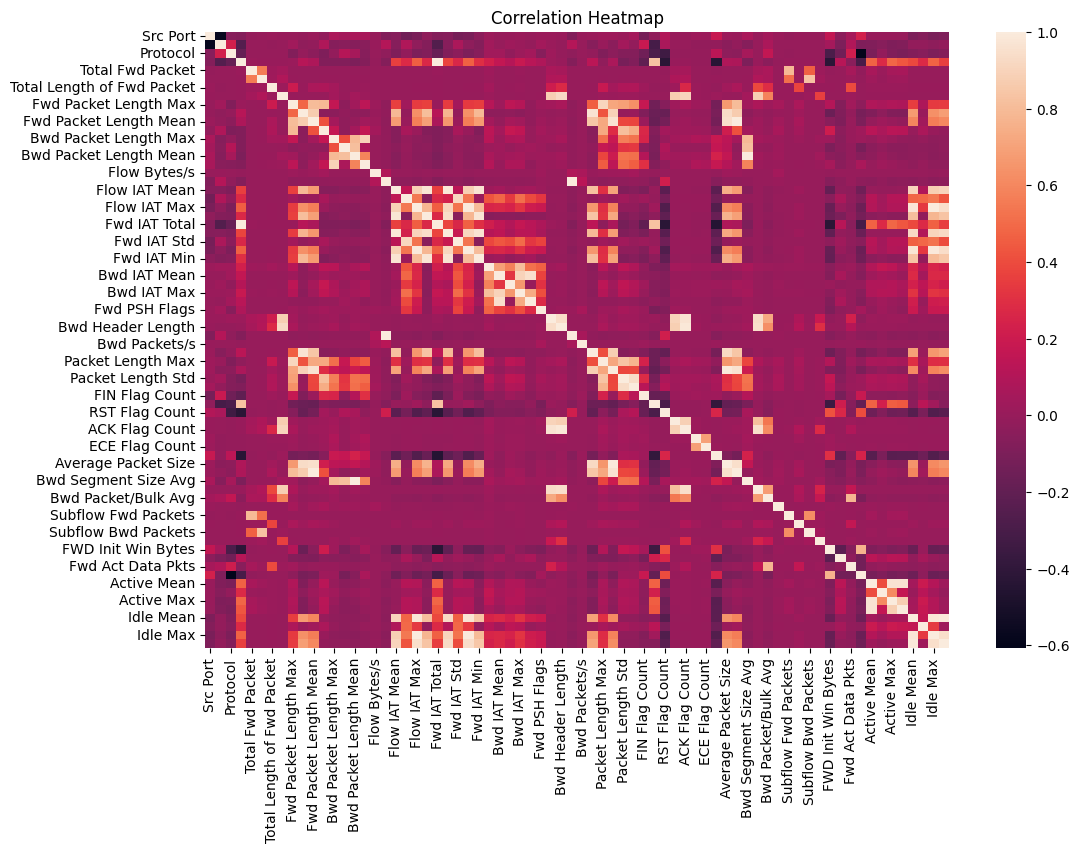

In [17]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), annot=False, fmt='.2f', cmap='rocket')
plt.title("Correlation Heatmap")
plt.show()

BALANCING THE DATA

In [14]:
print("Class distribution before SMOTE:", Counter(df["Label"]))

Class distribution before SMOTE: Counter({'Dos_SYN_Flood': 1048423, 'DoS-HTTPFlood': 670782, 'DDoS-HTTP_Flood': 499699, 'VulnerabilityScan': 441023, 'DDoS-ACK_Fragmentation': 121389, 'DNS_Spoofing': 74764, 'DoS-UDP_Flood': 74099, 'MITM-ArpSpoofing': 72968, 'benign': 38877, 'DDoS-ICMP_Fragmentation': 14456, 'DDoS_ICMP_Flood': 7785, 'SqlInjection': 6600, 'Mirai-greeth_flood': 5148, 'BruteForce': 3619, 'XSS': 3377, 'Uploading_Attack': 1348})


In [15]:
print(X.shape)
print(y.shape)

(3084357, 72)
(3084357,)


In [16]:
# Apply RandomOverSampler for class balancing
from imblearn.over_sampling import RandomOverSampler
def batch_resample(X, y, batch_size=10000):
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = [], []
    
    for i in range(0, len(X), batch_size):
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]
        
        if len(set(y_batch)) > 1:  # Ensure there are at least two classes
            X_r, y_r = ros.fit_resample(X_batch, y_batch)
            X_resampled.append(X_r)
            y_resampled.append(y_r)

    return np.vstack(X_resampled), np.hstack(y_resampled)

X_resampled, y_resampled = batch_resample(X, y)


In [17]:
X_resampled.shape, y_resampled.shape

((189391, 72), (189391,))

C:\Users\Mangalesh S\AppData\Local\Temp\ipykernel_15200\1423096910.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=value_counts.values, y=value_counts.index, palette="Blues_d")


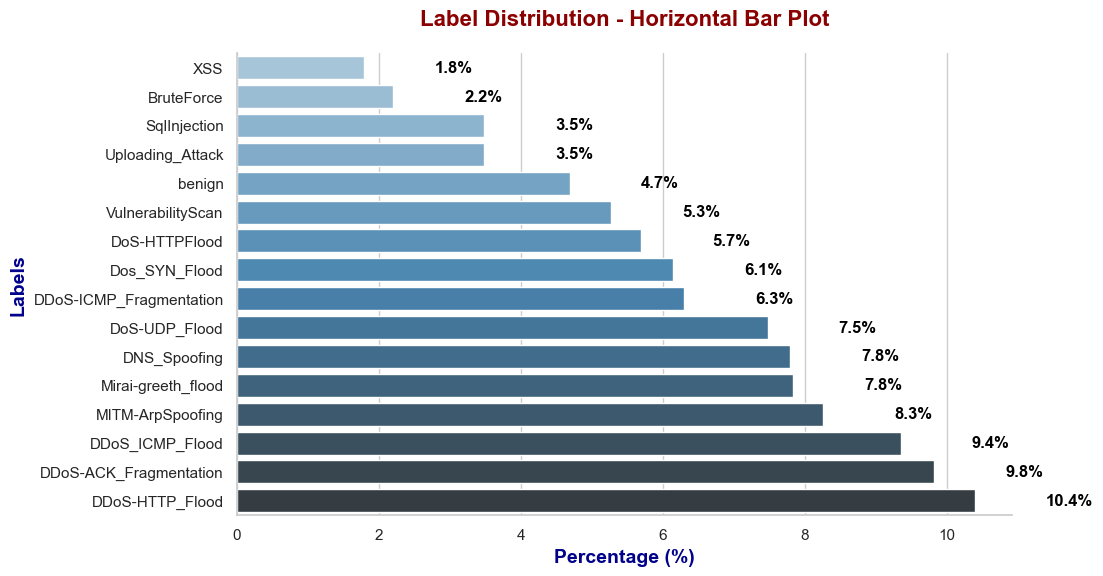

In [19]:
# Count unique labels and convert to percentages
value_counts = pd.Series(y_resampled).value_counts(normalize=True) * 100  # Convert to percentage

# Sort values for better readability
value_counts = value_counts.sort_values(ascending=True)

# Set figure size and style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", palette="muted")

# Create the horizontal bar plot
bars = sns.barplot(x=value_counts.values, y=value_counts.index, palette="Blues_d")

# Add percentage labels on the bars
for i, v in enumerate(value_counts.values):
    bars.text(v + 1, i, f'{v:.1f}%', color='black', ha='left', va='center', fontsize=12, fontweight='bold')

# Improve labels and title
plt.xlabel("Percentage (%)", fontsize=14, fontweight='bold', color='darkblue')
plt.ylabel("Labels", fontsize=14, fontweight='bold', color='darkblue')
plt.title("Label Distribution - Horizontal Bar Plot", fontsize=16, fontweight='bold', color='darkred', pad=20)

# Remove top and right borders for a clean look
sns.despine()

# Show the plot
plt.show()


C:\Users\Mangalesh S\AppData\Local\Temp\ipykernel_11968\2374470438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="rocket")


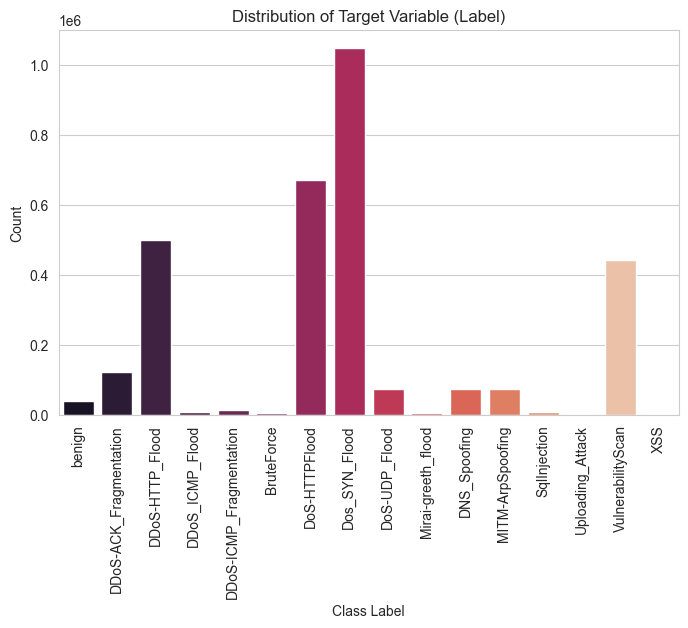

In [23]:
# Check class distribution in the target variable Before balancing
plt.figure(figsize=(8,5))
sns.countplot(x=y, palette="rocket")
plt.xticks(fontsize=10,rotation=90)
plt.title("Distribution of Target Variable (Label)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

C:\Users\Mangalesh S\AppData\Local\Temp\ipykernel_11968\2483517278.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette="rocket")


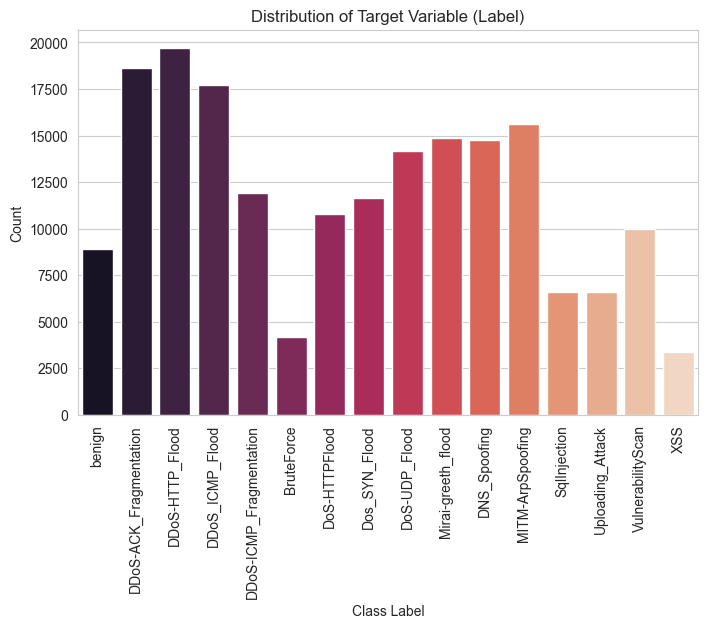

In [24]:
# Check class distribution in the target variable after balancing
plt.figure(figsize=(8, 5))
sns.countplot(x=y_resampled, palette="rocket")
plt.xticks(rotation=90,fontsize=10)
plt.title("Distribution of Target Variable (Label)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

In [17]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

Feature Selection

In [18]:
# Filter out classes with fewer than two samples
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index
X_filtered = X[y.isin(valid_classes)]
y_filtered = y[y.isin(valid_classes)]

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered)

In [19]:
from lightgbm import LGBMClassifier

In [ ]:
# Multi-Stage Hybrid Feature Selection
# Stage 1: Filter Method (Remove highly correlated features)
corr_threshold = 0.75
corr_matrix = pd.DataFrame(X_train).corr()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
features_to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > corr_threshold)]
X_train_filtered = X_train.drop(features_to_drop, axis=1)
X_test_filtered = X_test.drop(features_to_drop, axis=1)

# Stage 2: Wrapper Method (Recursive Feature Elimination)
model_for_rfe = LGBMClassifier(random_state=42, verbose=-1)
rfe_selector = RFE(estimator=model_for_rfe, n_features_to_select=35, step=0.03)
X_train_rfe = rfe_selector.fit_transform(X_train_filtered, y_train)
X_test_rfe = rfe_selector.T(X_test_filtered)
selected_features_rfe = X_train_filtered.columns[rfe_selector.get_support()]

# Stage 3: Embedded Method (Feature Importance from Random Forest)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_rfe, y_train)
importances = rf_model.feature_importances_
important_features = selected_features_rfe[np.argsort(importances)[-35:]]  # Top 35 features

c:\Users\Mangalesh S\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_selection\_rfe.py:300: UserWarning: Found n_features_to_select=35 > n_features=34. There will be no feature selection and all features will be kept.
  warnings.warn(
c:\Users\Mangalesh S\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


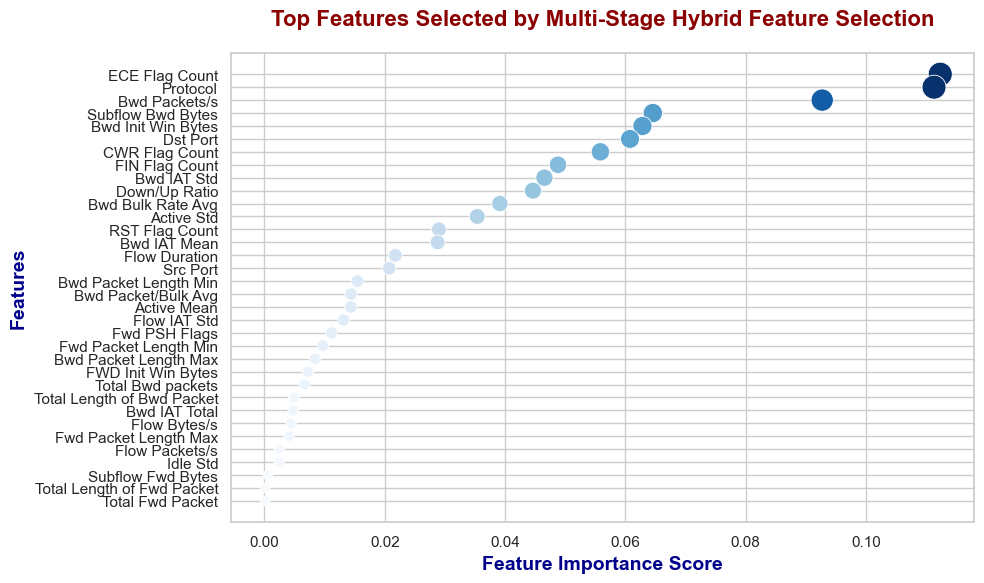

In [51]:
# Create a DataFrame for ease of manipulation
importance_df = pd.DataFrame({
    'Feature': important_features,
    'Importance': importances
})

# Sort features by importance
importance_df = importance_df.sort_values('Importance', ascending=False)

# Set up the dot plot
plt.figure(figsize=(10, 6))

# Create a dot plot where the color indicates the feature importance
sns.scatterplot(x='Importance', y='Feature', data=importance_df, size='Importance', hue='Importance', palette="Blues", sizes=(50, 300), legend=None, marker="o")

# Add titles and labels
plt.title('Top Features Selected by Multi-Stage Hybrid Feature Selection', fontsize=16, fontweight='bold', color='darkred', pad=20)
plt.xlabel('Feature Importance Score', fontsize=14, fontweight='bold', color='darkblue')
plt.ylabel('Features', fontsize=14, fontweight='bold', color='darkblue')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()


In [21]:
# Train a Final Model using Selected Features
final_X_train = X_train_rfe[:, np.argsort(importances)[-35:]]
final_X_test = X_test_rfe[:, np.argsort(importances)[-35:]]

final_model = DecisionTreeClassifier(max_depth=10, random_state=42)  # Restrict depth for speed
final_model.fit(final_X_train, y_train)
y_pred_dt = final_model.predict(final_X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")


Decision Tree Accuracy: 0.8887


In [31]:
X_train_rfe.shape 


(2467485, 34)

In [32]:
X_test_rfe.shape 


(616872, 34)

In [33]:
final_X_train.shape 


(2467485, 34)

In [34]:
final_X_test.shape


(616872, 34)

In [35]:
y_pred_dt.shape


(616872,)

In [36]:
y_train.shape

(2467485,)

FINE TUNING OF DATA

Grid Search

In [25]:
# 🔹 Reduced Parameter Grid for Grid Search
grid_param = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize model
dt = DecisionTreeClassifier(random_state=42)

# 🔹 Grid Search with reduced cv and n_jobs=1
grid_search = GridSearchCV(dt, grid_param, cv=2, scoring='accuracy', n_jobs=1, verbose=1)
grid_search.fit(final_X_train, y_train)

# Train final model with best Grid Search parameters
best_grid_params = grid_search.best_params_
grid_final_model = DecisionTreeClassifier(**best_grid_params, random_state=42)
grid_final_model.fit(final_X_train, y_train)

# Evaluate Grid Search model
y_pred_grid = grid_final_model.predict(final_X_test)
grid_accuracy = accuracy_score(y_test, y_pred_grid)
print(f"Grid Search Model Accuracy: {grid_accuracy:.4f}")

Fitting 2 folds for each of 12 candidates, totalling 24 fits
Grid Search Model Accuracy: 0.9314


Random Search

In [26]:
# 🔹 Reduced Parameter Distribution for Randomized Search
rand_param_dist = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Use an even smaller dataset for tuning
sample_indices = np.random.choice(final_X_train.shape[0], size=int(0.3 * final_X_train.shape[0]), replace=False)
X_sampled = final_X_train[sample_indices]
y_sampled = y_train.iloc[sample_indices]

# 🔹 Randomized Search with lower n_iter and cv
dt = DecisionTreeClassifier(random_state=42)
random_search = RandomizedSearchCV(
    dt, param_distributions=rand_param_dist, n_iter=12, cv=2,
    scoring='accuracy', n_jobs=1, random_state=42, verbose=1)
random_search.fit(X_sampled, y_sampled)

# Train final model with best Randomized Search parameters
best_rand_params = random_search.best_params_
rand_final_model = DecisionTreeClassifier(**best_rand_params, random_state=42)
rand_final_model.fit(final_X_train, y_train)

# Evaluate Randomized Search model
y_pred_rand = rand_final_model.predict(final_X_test)
rand_accuracy = accuracy_score(y_test, y_pred_rand)
print(f"Random Search Model Accuracy: {rand_accuracy:.4f}")

Fitting 2 folds for each of 12 candidates, totalling 24 fits
Random Search Model Accuracy: 0.9314


K fold classification

In [27]:
# 🔹 Memory-Efficient K-Fold Cross-Validation
kf = KFold(n_splits=2, shuffle=True, random_state=42)
cv_accuracies = []

for train_index, test_index in kf.split(final_X_train):
    X_train_fold, X_test_fold = final_X_train[train_index], final_X_train[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    model = DecisionTreeClassifier(max_depth=10, random_state=42)
    model.fit(X_train_fold, y_train_fold)
    
    y_pred_fold = model.predict(X_test_fold)
    acc = accuracy_score(y_test_fold, y_pred_fold)
    cv_accuracies.append(acc)

# Compute mean CV accuracy
mean_cv_accuracy = np.mean(cv_accuracies)
print(f"Cross-Validation Accuracy: {mean_cv_accuracy:.4f}")

Cross-Validation Accuracy: 0.8889


XGBoost Model

In [28]:
# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Classes:", label_encoder.classes_)

# Clean column names to avoid LightGBM issues
X.columns = X.columns.str.replace(' ', '_')

# CPU-Based XGBoost Model
xgb_model = XGBClassifier(tree_method='hist', random_state=42)
xgb_model.fit(X, y_encoded)
y_pred_xgb = xgb_model.predict(X)
xgb_accuracy = accuracy_score(y_encoded, y_pred_xgb)
print(f"XGBoost Model Accuracy: {xgb_accuracy:.4f}")

Classes: ['BruteForce' 'DDoS-ACK_Fragmentation' 'DDoS-HTTP_Flood'
 'DDoS-ICMP_Fragmentation' 'DDoS_ICMP_Flood' 'DNS_Spoofing'
 'DoS-HTTPFlood' 'DoS-UDP_Flood' 'Dos_SYN_Flood' 'MITM-ArpSpoofing'
 'Mirai-greeth_flood' 'SqlInjection' 'Uploading_Attack'
 'VulnerabilityScan' 'XSS' 'benign']
XGBoost Model Accuracy: 0.9435


Random Forest with BEST Parameters

In [24]:
# Create a random forest best parameters
rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=None,     # Limited tree depth
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=False,
    random_state=42
)

# Fit the model
rf.fit(final_X_train, y_train)

# Get training accuracy
rf_accuracy = rf.score(final_X_train, y_train)

print(f"Training Accuracy: {rf_accuracy:.4f}")

Training Accuracy: 0.9928


MODEL EVALUATION

In [29]:
accuracy = accuracy_score(y_test_fold[:len(train_index)], y_pred_fold[:len(train_index)])
classification_rep = classification_report(y_test_fold[:len(train_index)], y_pred_fold[:len(train_index)])
cv_scores = cross_val_score(final_model, X_train_fold, y_train_fold, cv=5)


c:\Users\Mangalesh S\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Mangalesh S\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Mangalesh S\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _wa

In [34]:
# Display Results
print("Selected Features After Multi-Stage Selection [20]:\n",important_features)
print("\nClassification Report:\n", classification_rep)
print("\nAccuracy on Test Set:", accuracy)

Selected Features After Multi-Stage Selection [20]:
 Index(['CWR Flag Count', 'ECE Flag Count', 'Fwd PSH Flags',
       'Subflow Bwd Bytes', 'Active Std', 'Bwd Packet/Bulk Avg',
       'Bwd Bulk Rate Avg', 'Bwd Packet Length Min', 'Bwd IAT Std',
       'Bwd IAT Mean', 'Active Mean', 'Bwd IAT Total', 'FIN Flag Count',
       'Protocol', 'Down/Up Ratio', 'Bwd Packet Length Max',
       'Total Bwd packets', 'Total Length of Bwd Packet', 'Subflow Fwd Bytes',
       'Bwd Init Win Bytes', 'Fwd Packet Length Min', 'RST Flag Count',
       'Total Fwd Packet', 'Total Length of Fwd Packet', 'Flow IAT Std',
       'Fwd Packet Length Max', 'Flow Bytes/s', 'Src Port', 'Idle Std',
       'Bwd Packets/s', 'Flow Duration', 'FWD Init Win Bytes',
       'Flow Packets/s', 'Dst Port'],
      dtype='object')

Classification Report:
                          precision    recall  f1-score   support

             BruteForce       0.00      0.00      0.00      1468
 DDoS-ACK_Fragmentation       1.00      0.91 

In [35]:
print("\nAccuracy on Test Set:", accuracy)
print(f"K-fold Cross-Validation Accuracy: {mean_cv_accuracy:.4f}")
print(f"Grid Search Model Accuracy: {grid_accuracy:.4f}")
print(f"Random Search Model Accuracy: {rand_accuracy:.4f}")
print(f'XGBoosting Accuracy: {xgb_accuracy:.4f}')
print(f'Random Forest Accuracy: {rf_accuracy:.4f}')


Accuracy on Test Set: 0.8889289656994737
K-fold Cross-Validation Accuracy: 0.8889
Grid Search Model Accuracy: 0.9314
Random Search Model Accuracy: 0.9314
XGBoosting Accuracy: 0.9435
Random Forest Accuracy: 0.9928


Peformence comparison for best Model

In [44]:
# Create lists of model names and their corresponding accuracies
models = ['K-Fold CV', 'Grid Search', 'Random Search', 'XGBoost', 'Random Forest']
accuracies = [mean_cv_accuracy, grid_accuracy, rand_accuracy, xgb_accuracy, rf_accuracy]

C:\Users\Mangalesh S\AppData\Local\Temp\ipykernel_12860\3652047127.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=accuracies, y=models, palette="deep")


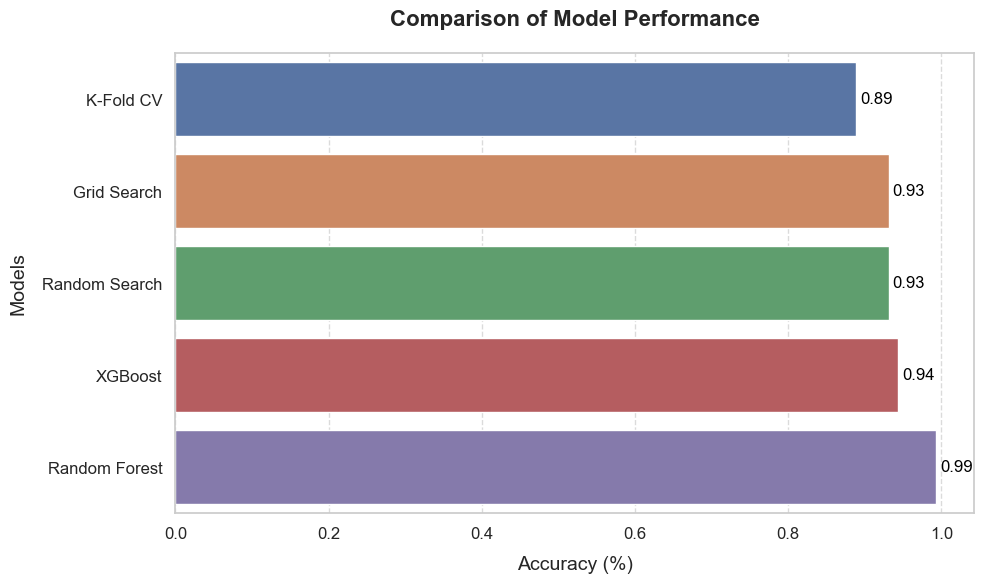

In [40]:
# Set a formal style for the plot
sns.set_theme(style="whitegrid", palette="muted")

# Create a horizontal bar plot
plt.figure(figsize=(10, 6))
bars = sns.barplot(x=accuracies, y=models, palette="deep")

# Customize the plot for clarity and readability
plt.title('Comparison of Model Performance', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Accuracy (%)', fontsize=14, labelpad=10)
plt.ylabel('Models', fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add accuracy values on the bars, formatted to 2 decimal places
for i, v in enumerate(accuracies):
    bars.text(v + 0.005, i, f'{v:.2f}', color='black', ha="left", va="center", fontsize=12)

# Add grid lines for better comparison
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Adjust layout to make sure labels fit and plot is aesthetically pleasing
plt.tight_layout()

# Show the plot
plt.show()


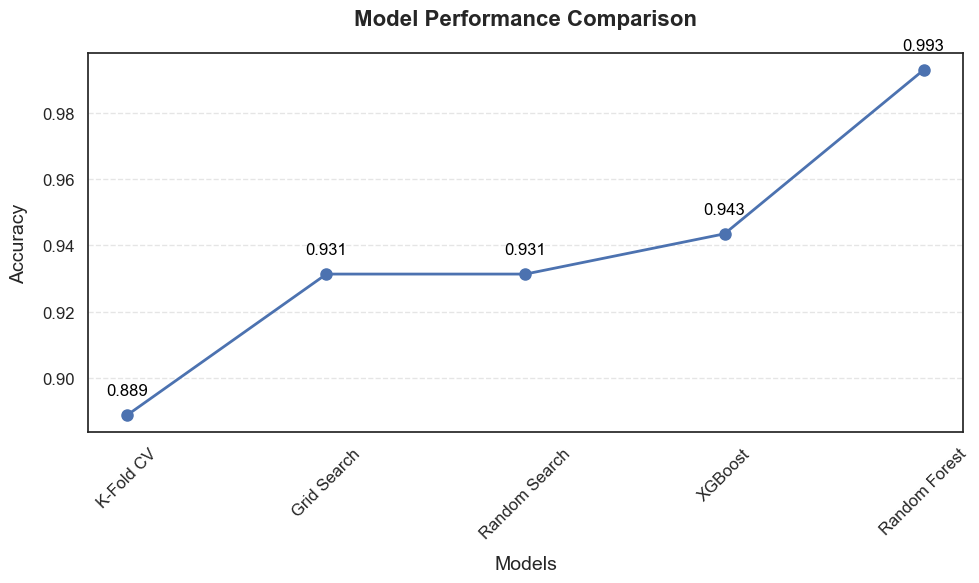

In [ ]:
# Set a formal style for the plot (minimalistic style)
sns.set_theme(style="white", palette="deep")

# Create a line plot with scatter points
plt.figure(figsize=(10, 6))

# Plot the scatter plot with line connection (corrected markersize)
plt.plot(models, accuracies, marker='o', color='b', linestyle='-', linewidth=2, markersize=8)

# Customize the plot for clarity and readability
plt.title('Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Models', fontsize=14, labelpad=10)
plt.ylabel('Accuracy', fontsize=14, labelpad=10)

# Annotate the accuracy values with a more formal style
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f'{v:.3f}', color='black', ha="center", va="bottom", fontsize=12)

# Set the font size for the tick labels
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Customize gridlines for a cleaner look
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Adjust layout to ensure everything fits properly
plt.tight_layout()

# Show the plot
plt.show()